In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report,
    r2_score, mean_squared_error, root_mean_squared_error, 
    mean_absolute_error, mean_absolute_percentage_error, RocCurveDisplay
)
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBClassifier

**Goal:** Predict the rank based of each match.

Creating a function to prep the raw data:

In [3]:
def prep_rocket_league_data(file):
    # Read in the data
    # Drop assists since it is 0 for 1v1; drop mvp since there is always 1 mvp per match
    matches = pd.read_csv(f'../data/{file}').drop(columns=['assists','mvp'])

    # First, we'll pivot the data so that we preserve the individual player stats for each match.
    matches_subset = matches.drop(columns=['map_code','rank','duration'], errors='ignore')
    matches_subset_pivoted = matches_subset.pivot(index='match_id', columns='color', values=[col for col in matches_subset.columns if col != 'match_id' and col != 'color'])                                               
    matches_subset_pivoted.columns = matches_subset_pivoted.columns.map(lambda x: f"{x[0]}_{x[1]}")       

    # Make sure numeric columns have a numeric data type
    cols_to_convert = [col for col in matches_subset_pivoted.columns if col not in ['match_id','car_name_blue','car_name_orange']]
    matches_subset_pivoted[cols_to_convert] = matches_subset_pivoted[cols_to_convert].astype('float64')  

    # Next we'll aggregate the original matches data so that we have 1 row per match containing both the mean and difference of all numeric variables.
    # For map_code, we'll just use max since it is the same value for both players. 
    # For all numeric variables, we'll take both the mean and difference.

    # Define aggregation
    agg_dict = {col: ["mean",(lambda x: x.max() - x.min())] for col in matches.select_dtypes('number').columns if col != 'match_id'}
    agg_dict.update({"map_code": "max"})

    # Apply aggregation
    if 'rank' in matches.columns:
        matches_prepped = matches.drop(columns=['car_name']).groupby(['match_id','rank']).agg(agg_dict).reset_index()
    else:
        matches_prepped = matches.drop(columns=['car_name']).groupby('match_id').agg(agg_dict).reset_index()

    # Rename columns 
    matches_prepped.columns = matches_prepped.columns.map(lambda x: f"{x[0]}_{x[1]}".replace("_<lambda_0>", "_diff").strip("_"))

    # Dropping duration_diff since it is 0 across the board and rename duration_mean to just duration.
    # Also rename map_code_max to map_code for clarity
    matches_prepped = matches_prepped.drop(columns=['duration_diff']).rename(columns={'map_code_max':'map_code','duration_mean':'duration'})

    # Finally we'll merge the 2 prepared dataframes so that we have individual player stats and aggregated match stats for each match.
    matches_prepped_final = pd.merge(matches_subset_pivoted, matches_prepped, how='inner', on='match_id')

    return matches_prepped_final

Prep the labeled data:

In [4]:
matches_prepped_final = prep_rocket_league_data('train.csv')

In [5]:
matches_prepped_final.head()

,match_id,car_name_blue,car_name_orange,possession_time_blue,possession_time_orange,time_in_side_blue,time_in_side_orange,shots_blue,shots_orange,shots_against_blue,...,percent_most_forward_diff,percent_closest_to_ball_mean,percent_closest_to_ball_diff,percent_farthest_from_ball_mean,percent_farthest_from_ball_diff,demos_inflicted_mean,demos_inflicted_diff,demos_taken_mean,demos_taken_diff,map_code
0,0,Breakout,Octane,54.95,27.51,58.96,80.68,2.0,4.0,4.0,...,2.770090,96.919125,2.770090,96.919125,2.770090,0.5,1,0.5,1,neotokyo_standard_p
1,1,Octane,Octane,132.98,102.55,244.72,148.84,7.0,10.0,10.0,...,0.023930,96.930475,0.023930,96.930475,0.023930,0.0,0,0.0,0,stadium_foggy_p
2,2,Octane,Octane,25.24,18.01,33.70,47.41,0.0,3.0,3.0,...,0.117190,93.695065,0.117190,93.695065,0.117190,0.0,0,0.0,0,neotokyo_standard_p
3,3,Fennec,Octane,98.15,131.22,185.96,115.92,9.0,3.0,3.0,...,0.000000,97.936844,0.000000,97.936844,0.000000,1.0,2,1.0,2,stadium_day_p
4,4,Octane,Octane,140.71,120.08,147.00,183.97,8.0,8.0,8.0,...,0.029156,98.323618,0.029156,98.323618,0.029156,0.0,0,0.0,0,trainstation_dawn_p


Submission #1: decision tree forest 

In [207]:
# Our features are everything except for match id and rank
variables = [col for col in matches_prepped_final.columns if col != 'match_id' and col != 'rank']

# We'll apply a SimpleImputer and a StandardScaler to numeric features
numeric_features = [col for col in matches_prepped_final.select_dtypes('number').columns if col != 'match_id']
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ("scaler", StandardScaler())]
)

# We'll apply a one-hot encoder to the categorical features
categorical_features = [col for col in matches_prepped_final.select_dtypes('object').columns if col != 'rank']
categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Append classifier to preprocessing pipeline. Now we have a full prediction pipeline.
rf_pipe = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", RandomForestClassifier(n_estimators=1000))]
)

X = matches_prepped_final[variables]
y = matches_prepped_final['rank']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0, stratify=y)

rf_pipe.fit(X_train, y_train)

y_pred = rf_pipe.predict(X_test)

In [208]:
score = f1_score(y_test, y_pred, average='micro')

print(f"F1 Score: {score}")

print("Precision Score : ",precision_score(y_test, y_pred, 
                                           average='micro'))
                                           
print("Recall Score : ",recall_score(y_test, y_pred, 
                                           average='micro'))

F1 Score: 0.5351214978090559
Precision Score :  0.5351214978090559
Recall Score :  0.5351214978090559


In [209]:
# Refit the model on all of the available training data.
rf = rf_pipe.fit(X, y)

# Prep unlabeled data
test_prepped_final = prep_rocket_league_data('test.csv')

# Define variables
variables = [col for col in test_prepped_final.columns if col != 'match_id']

# Generate predictions on the test set by applying the model
y_pred = rf.predict(test_prepped_final[variables])

# Convert string ranks to numeric
converter = { 'bronze': 1, 'silver': 2, 'gold': 3, 'platinum': 4, 'diamond': 5, 'champion': 6 }
y_pred = pd.Series(y_pred).map(converter)

# Concatenate the match ids in the test set with the model predictions to create the final submission
submission = pd.concat([test_prepped_final['match_id'], y_pred], axis = 1).rename(columns = {0: 'rank'})

# Save submission to csv
submission.to_csv('../data/submission1.csv', index = False)

In [210]:
names = rf[:-1].get_feature_names_out()

values = rf['model'].feature_importances_

feature_table = pd.DataFrame({'feature_name':names, 'feature_importance':values})

feature_table.sort_values(by='feature_importance', ascending=False)

,feature_name,feature_importance
269,num__percent_supersonic_speed_mean,1.737626e-02
273,num__percent_low_air_mean,1.385713e-02
187,num__bcpm_mean,1.351396e-02
271,num__percent_ground_mean,1.336268e-02
245,num__time_supersonic_speed_mean,1.021145e-02
...,...,...
417,cat__car_name_orange_Aftershock,7.396192e-08
354,cat__car_name_blue_Ecto-1,6.745618e-08
452,cat__car_name_orange_MR11,0.000000e+00
373,cat__car_name_blue_MR11,0.000000e+00


In [ ]:
for i in converter.keys():
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_title("Partial Dependence Plots")
    
    PartialDependenceDisplay.from_estimator(
        estimator=rf,
        X=X,
        target=i,
        features=['percent_supersonic_speed','bcpm'], # the features to plot
        random_state=5,
        ax=ax,
    )
    
    plt.show()

Submission #2: gradient boosted decision tree 

In [211]:
# Our features are everything except for match id and rank
variables = [col for col in matches_prepped_final.columns if col != 'match_id' and col != 'rank']

# We'll apply a SimpleImputer and a StandardScaler to numeric features
numeric_features = [col for col in matches_prepped_final.select_dtypes('number').columns if col != 'match_id']
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ("scaler", StandardScaler())]
)

# We'll apply a one-hot encoder to the categorical features
categorical_features = [col for col in matches_prepped_final.select_dtypes('object').columns if col != 'rank']
categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Append classifier to preprocessing pipeline. Now we have a full prediction pipeline.
gb_pipe = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", GradientBoostingClassifier(n_estimators=100))]
)

X = matches_prepped_final[variables]
y = matches_prepped_final['rank']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0, stratify=y)

gb_pipe.fit(X_train, y_train)

y_pred = gb_pipe.predict(X_test)

In [14]:
score = f1_score(y_test, y_pred, average='micro')

print(f"F1 Score: {score}")

print("Precision Score : ",precision_score(y_test, y_pred, 
                                           average='micro'))
                                           
print("Recall Score : ",recall_score(y_test, y_pred, 
                                           average='micro'))

F1 Score: 0.5422918603107157
Precision Score :  0.5422918603107157
Recall Score :  0.5422918603107157


In [212]:
# Refit the model on all of the available training data.
gb = gb_pipe.fit(X, y)

# Prep unlabeled data
test_prepped_final = prep_rocket_league_data('test.csv')

# Define variables
variables = [col for col in test_prepped_final.columns if col != 'match_id']

# Generate predictions on the test set by applying the model
y_pred = gb.predict(test_prepped_final[variables])

# Convert string ranks to numeric
converter = { 'bronze': 1, 'silver': 2, 'gold': 3, 'platinum': 4, 'diamond': 5, 'champion': 6 }
y_pred = pd.Series(y_pred).map(converter)

# Concatenate the match ids in the test set with the model predictions to create the final submission
submission = pd.concat([test_prepped_final['match_id'], y_pred], axis = 1).rename(columns = {0: 'rank'})

# Save submission to csv
submission.to_csv('../data/submission2.csv', index = False)

Looking at the most important features:

In [213]:
names = gb[:-1].get_feature_names_out()

values = gb['model'].feature_importances_

feature_table = pd.DataFrame({'feature_name':names, 'feature_importance':values})

feature_table.sort_values(by='feature_importance', ascending=False)

,feature_name,feature_importance
269,num__percent_supersonic_speed_mean,0.255302
187,num__bcpm_mean,0.114031
273,num__percent_low_air_mean,0.064889
267,num__percent_boost_speed_mean,0.064134
271,num__percent_ground_mean,0.058490
...,...,...
380,cat__car_name_blue_McLaren 570S,0.000000
381,cat__car_name_blue_Merc,0.000000
383,cat__car_name_blue_Mudcat G1,0.000000
384,cat__car_name_blue_Mudcat GXT,0.000000


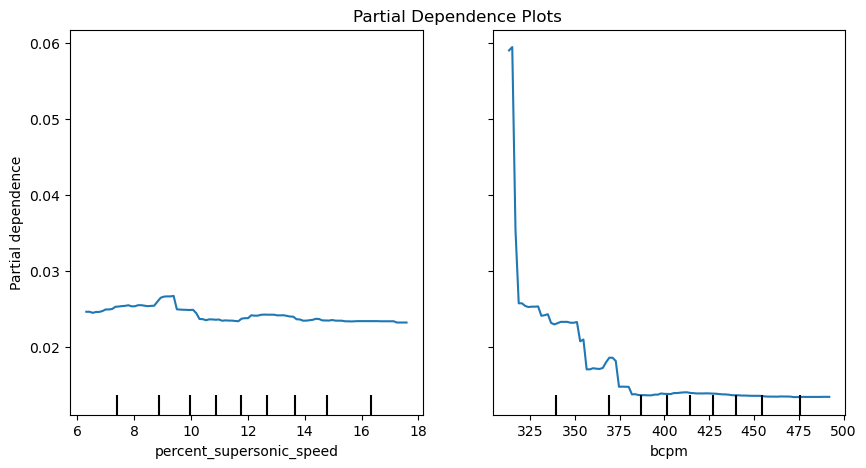

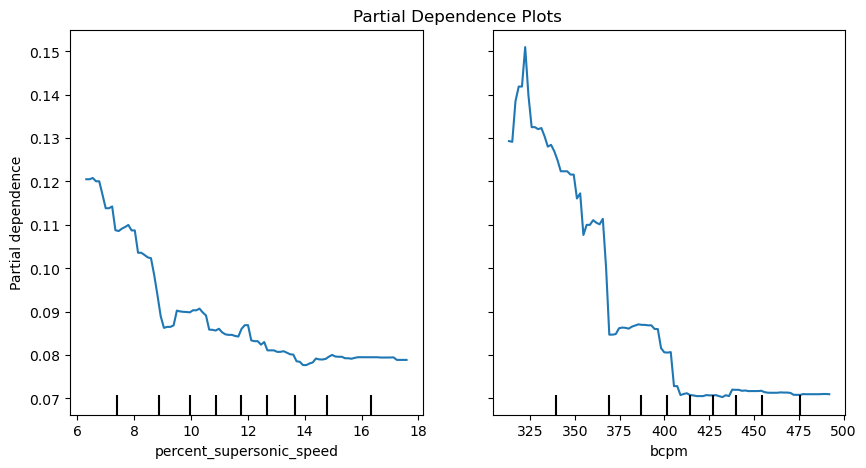

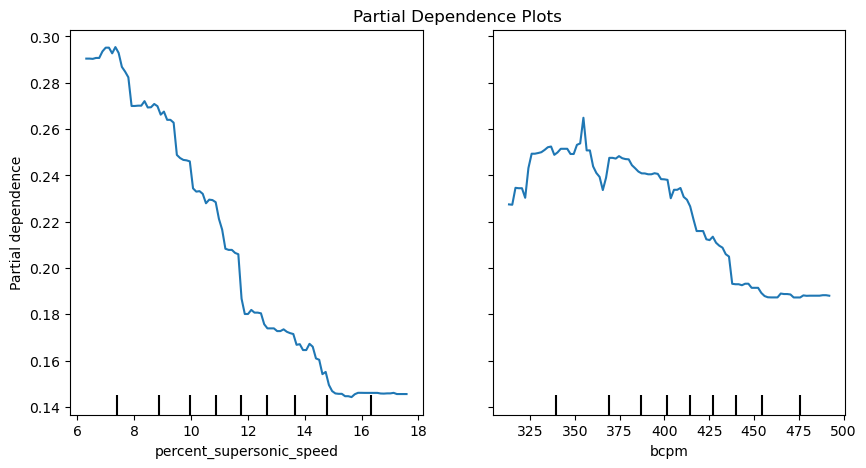

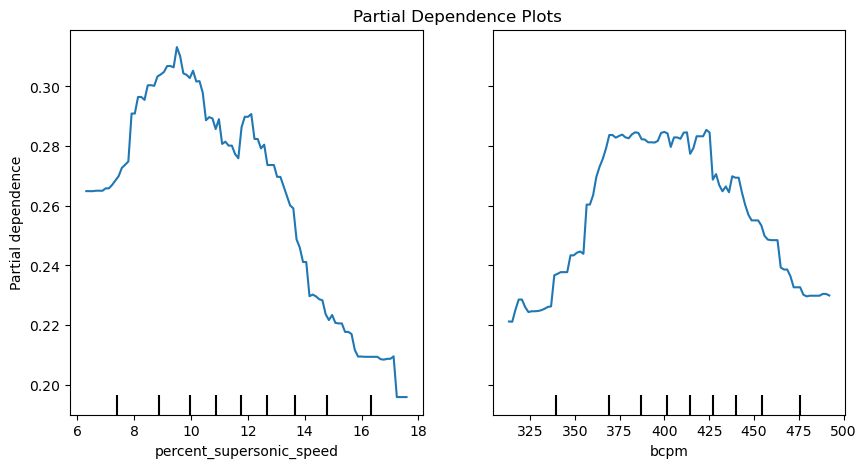

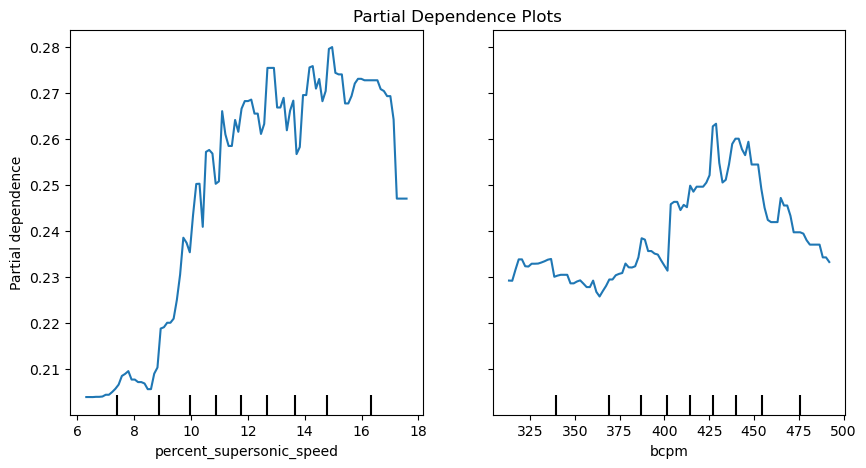

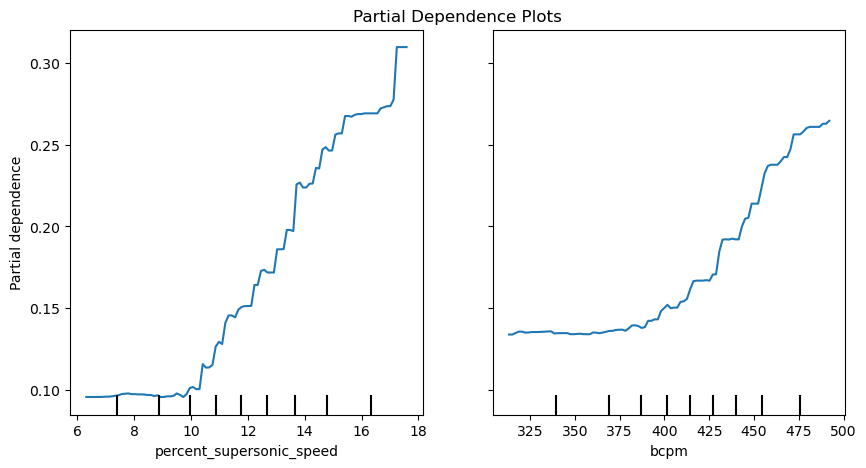

In [36]:
for i in converter.keys():
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_title("Partial Dependence Plots")
    
    PartialDependenceDisplay.from_estimator(
        estimator=gb,
        X=X,
        target=i,
        features=['percent_supersonic_speed','bcpm'], # the features to plot
        random_state=5,
        ax=ax,
    )
    
    plt.show()

Submission #3: Using XGBoost

In [37]:
# Our features are everything except for match id and rank
variables = [col for col in matches_prepped_final.columns if col != 'match_id' and col != 'rank']

# We'll apply a SimpleImputer and a StandardScaler to numeric features
numeric_features = [col for col in matches_prepped_final.select_dtypes('number').columns if col != 'match_id']
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ("scaler", StandardScaler())]
)

# We'll apply a one-hot encoder to the categorical features
categorical_features = [col for col in matches_prepped_final.select_dtypes('object').columns if col != 'rank']
categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Append classifier to preprocessing pipeline. Now we have a full prediction pipeline.
xg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", XGBClassifier(n_estimators=1000))
])

X = matches_prepped_final[variables]
y = matches_prepped_final['rank']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0, stratify=y)

# Encode target 
# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train and y_test
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

xg_pipe.fit(X_train, y_train)

y_pred = xg_pipe.predict(X_test)

In [38]:
score = f1_score(y_test, y_pred, average='micro')

print(f"F1 Score: {score}")

print("Precision Score : ",precision_score(y_test, y_pred, 
                                           average='micro'))
                                           
print("Recall Score : ",recall_score(y_test, y_pred, 
                                           average='micro'))

F1 Score: 0.5481343779046607
Precision Score :  0.5481343779046607
Recall Score :  0.5481343779046607


In [39]:
y = matches_prepped_final['rank']

# Encode target 
# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y
y = le.fit_transform(y)

# Refit the model on all of the available training data.
xg = xg_pipe.fit(X, y)

# Prep unlabeled data
test_prepped_final = prep_rocket_league_data('test.csv')

# Define variables
variables = [col for col in test_prepped_final.columns if col != 'match_id']

# Generate predictions on the test set by applying the model
y_pred_raw = xg.predict(test_prepped_final[variables])

# Revert the label encodings for the target 
y_pred = le.inverse_transform(y_pred_raw)

In [40]:
# Convert string ranks to numeric
converter = { 'bronze': 1, 'silver': 2, 'gold': 3, 'platinum': 4, 'diamond': 5, 'champion': 6 }
y_pred = pd.Series(y_pred).map(converter)

# Concatenate the match ids in the test set with the model predictions to create the final submission
submission = pd.concat([test_prepped_final['match_id'], y_pred], axis = 1).rename(columns = {0: 'rank'})

# Save submission to csv
submission.to_csv('../data/submission3.csv', index = False)

In [41]:
names = xg[:-1].get_feature_names_out()

values = xg['model'].feature_importances_

feature_table = pd.DataFrame({'feature_name':names, 'feature_importance':values})

feature_table.sort_values(by='feature_importance', ascending=False)

,feature_name,feature_importance
269,num__percent_supersonic_speed_mean,0.054711
187,num__bcpm_mean,0.021271
271,num__percent_ground_mean,0.015498
273,num__percent_low_air_mean,0.014687
261,num__avg_powerslide_duration_mean,0.014525
...,...,...
412,cat__car_name_blue_Zippy,0.000000
414,cat__car_name_orange_'70 Dodge Charger R/T,0.000000
415,cat__car_name_orange_'89 Batmobile,0.000000
331,num__demos_taken_mean,0.000000
